<a href="https://colab.research.google.com/github/jmorenohj/Grupo-5-Fairness-in-Crime/blob/main/v3_crime_convlstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de tipos de crimen con ConvLSTM

En este cuaderno presentamos el procedimiento para el proyecto de RN del grupo 5.

1. Carga de datos y partición de sets de train-validación.
2. **Construir** un modelo usando **ConvLSTM** con TensorFlow/Keras, y
3. **Entrenar** el modelo con los datos generados.

El objetivo es que cada celda (pixel) en cada imagen (frame temporal) contenga una **distribución de 3 clases** (theft, battery, criminal damage), es decir, cada celda suma 1 en los tres canales.


## 1. Importación de librerías

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv3D
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, Image

print("Versión de TensorFlow:", tf.__version__)


Versión de TensorFlow: 2.18.0


## 2. Carga del conjunto de datos


In [ ]:
import pickle
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the file
shared_folder_path = '/content/drive/Shared drives/Redes Neuronales/Proyecto/Entrega final/images/'
video_file_path = os.path.join(shared_folder_path, 'video_daily_long.pkl')

# Try loading the file
try:
    with open(video_file_path, "rb") as file:
        video_data = pickle.load(file)
    print("File loaded successfully!")
    print(f"Data type: {type(video_data)}")
    print(f"Shape: {video_data.shape if isinstance(video_data, np.ndarray) else 'Unknown'}")
except pickle.UnpicklingError:
    print("Error: The file may be corrupted or truncated.")
except FileNotFoundError:
    print("Error: File not found, check the path.")
except Exception as e:
    print(f"Unexpected error: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File loaded successfully!
Data type: <class 'numpy.ndarray'>
Shape: (1126, 41, 34, 3)


In [ ]:
video_data_cont = video_data.reshape(-1, 41, 34, 3)  # Shape becomes (9528, 41, 34, 3)
video_data_cont.shape

(1126, 41, 34, 3)

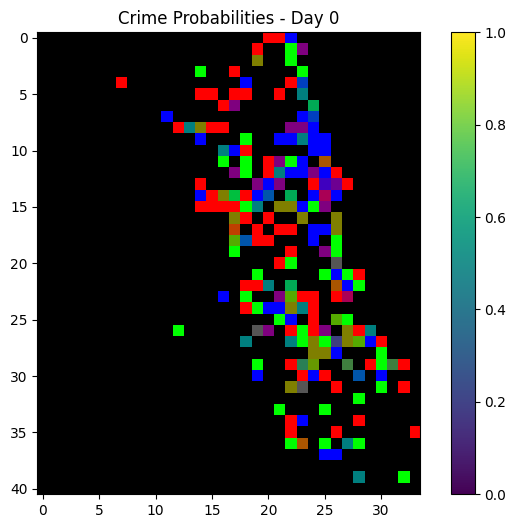

In [ ]:
import matplotlib.pyplot as plt

# Select a specific day and hour to visualize
day = 0

# Extract the image for that specific time step
image = video_data[day,  :, :, :]

# Plot it
plt.figure(figsize=(8, 6))
plt.imshow(image)  # Assuming the last dimension is RGB
plt.title(f"Crime Probabilities - Day {day}")
plt.colorbar()
plt.show()


## 3. Función para generar los conjuntos de datos.


In [ ]:
from sklearn.model_selection import train_test_split
def prepare_data(video_data, timesteps=6, future_steps=6):
    """
    Prepares X and Y:
    - X: Past `timesteps` frames
    - Y: The next `future_steps` frames
    """
    num_days = 1095
    X_list, Y_list = [], []

    for day in range(num_days- timesteps - future_steps + 1):
        X_list.append(video_data[day:day+timesteps])
        Y_list.append(video_data[day+timesteps:day+timesteps+future_steps])

    X = np.array(X_list)  # Shape: (samples, timesteps, height, width, 3)
    Y = np.array(Y_list)  # Shape: (samples, future_steps, height, width, 3)

    return X, Y

# Example usage
X, Y = prepare_data(video_data, timesteps=2, future_steps=1)
print("X shape:", X.shape)  # (samples, timesteps, height, width, 3)
print("Y shape:", Y.shape)  # (samples, future_steps, height, width, 3)

X_train, X_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X shape: (1093, 2, 41, 34, 3)
Y shape: (1093, 1, 41, 34, 3)


## 4. Definición del modelo con ConvLSTM

Construiremos un modelo secuencial con:

1. Varias capas **ConvLSTM2D** con `return_sequences=True` para procesar secuencias.
2. **BatchNormalization** para estabilizar el entrenamiento.
3. Capas densas al final para generar la salida con activación sigmoide.
4. Se disena la arquitectura para tener en cuenta 7 días al generar la predicción.


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM2D, BatchNormalization, Flatten, Dense, RepeatVector, Reshape, TimeDistributed, Dropout
from tensorflow.keras.initializers import RandomNormal
# Define parameters
timesteps = 7       # Number of input frames
future_steps = 1   # Number of frames to predict ( 30 days)
height = 41          # Spatial dimension (height)
width = 34           # Spatial dimension (width)
channels = 3

# Encoder: Process the input sequence and produce a latent representation.
input_layer = Input(shape=(timesteps, height, width, channels))
x = ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = ConvLSTM2D(filters=64, kernel_size=(3, 3), padding='same', return_sequences=True, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=False, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Flatten the spatial dimensions so we get a 1D latent vector.
x = Flatten()(x)

# Decoder: Repeat the latent vector for each future timestep.
#x = RepeatVector(future_steps)(x)  # Now x has shape (batch, future_steps, latent_dim)

# Decode each timestep back to an image.
# The target is an image of size (height, width, channels)
units = height * width * channels
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(units, activation='sigmoid')(x)
x = Reshape((1,height, width, channels))(x)

# Build and compile the model.
model = Model(inputs=input_layer, outputs=x)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 2, 41, 34, 3)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)           │ (None, 2, 41, 34, 64)       │         154,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 2, 41, 34, 64)       │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 2, 41, 34, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_4 (ConvLSTM2D)           │ (None, 2, 41, 34, 64)       │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 2, 41, 34, 64)       │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 2, 41, 34, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_5 (ConvLSTM2D)           │ (None, 41, 34, 32)          │         110,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 41, 34, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 41, 34, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 44608)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       5,709,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4182)                │         539,478 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 1, 41, 34, 3)        │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,810,582 (25.98 MB)

 Trainable params: 6,810,262 (25.98 MB)

 Non-trainable params: 320 (1.25 KB)

## 5. Entrenamiento del modelo

Dividiremos nuestros datos sintéticos en conjunto de entrenamiento y validación (por ejemplo 80/20), y entrenaremos por unas cuantas épocas (4 épocas de ejemplo).

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import os

# Carpeta donde se guardarán los pesos del modelo
checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Nombre del archivo de guardado con la mejor época
checkpoint_path = os.path.join(checkpoint_dir, 'model_best_epoch.weights.h5')

# Callback para guardar el mejor modelo basado en la métrica de validación
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='accuracy',              # Métrica para evaluar la mejor época
    save_best_only=True,             # Solo guarda si mejora
    save_weights_only=True,          # Solo guarda los pesos (no la arquitectura completa)
    mode='min',                      # Modo 'min' porque queremos minimizar la pérdida
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='loss',  # Métrica a monitorear
    factor=0.5,          # Reducir a la mitad
    patience=3,          # Espera 3 épocas antes de reducir
    min_lr=1e-6          # Limite inferior del learning rate
)

# Compilar el modelo con la pérdida correcta
model.compile(loss='mse', optimizer=Adam(learning_rate=0.01), metrics=['accuracy','mae'])

# Entrenar el modelo con los callbacks
history = model.fit(
    X_train, y_train,
    validation_data=(X_temp,y_temp),
    epochs=5,                       # Número de épocas
    batch_size=4,                    # Tamaño del batch
    callbacks=[checkpoint_callback,reduce_lr]
)

Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8707 - loss: 0.0578 - mae: 0.0725
Epoch 1: accuracy improved from inf to 0.89833, saving model to ./checkpoints/model_best_epoch.weights.h5
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.8709 - loss: 0.0578 - mae: 0.0724 - val_accuracy: 0.8574 - val_loss: 0.0640 - val_mae: 0.0705 - learning_rate: 0.0100
Epoch 2/5
191/192 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9051 - loss: 0.0487 - mae: 0.0548
Epoch 2: accuracy did not improve from 0.89833
192/192 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9051 - loss: 0.0487 - mae: 0.0548 - val_accuracy: 0.8930 - val_loss: 0.0485 - val_mae: 0.0547 - learning_rate: 0.0100
Epoch 3/5
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9054 - loss: 0.0489 - mae: 0.0550
Epoch 3: accuracy did not improve from 0.89833
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9054 - loss: 0.0489 - mae: 0.0550 - val_accuracy: 0.9056 - val_loss: 0.0484 - val_mae: 0.0546 

In [ ]:
model.load_weights(checkpoint_path)

### 6. Se predice un mes entero usando una ventana de tiempo de 7 días.

In [ ]:

prediction_size = 15
starting_day = 1095
results = []
window =np.array(video_data[starting_day-timesteps:starting_day])
for i in range(prediction_size):
    prediction = model.predict(np.expand_dims(window, axis=0))
    prediction = prediction[0]
    results.append(prediction[0])
    window = np.append(window[1:], prediction, axis=0)

real = video_data[starting_day:starting_day+prediction_size]
print(real.shape,np.array(results).shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Melo
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Melo
(15, 41, 34, 3) (15, 41, 34, 3)


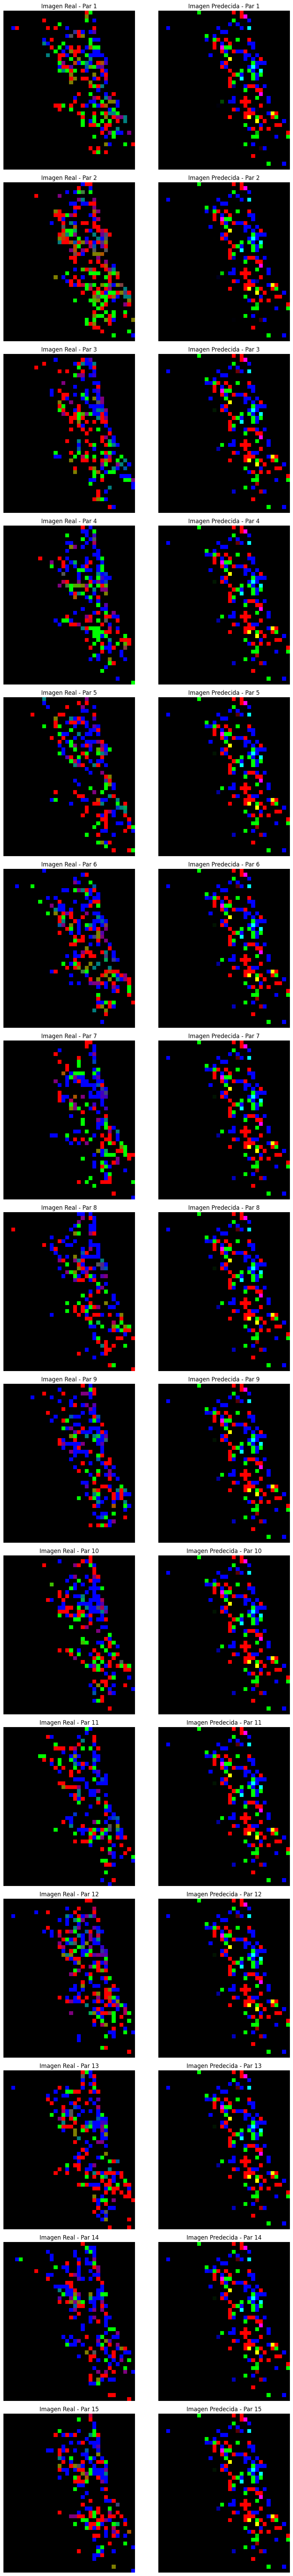

In [ ]:
fig, axs = plt.subplots(len(real), 2, figsize=(10, len(real) * 5))

    # Si solo hay un par, ajustar la forma de axs
if len(real) == 1:
    axs = [axs]

    # Iterar sobre las imágenes y mostrarlas en filas
for i, (img1, img2) in enumerate(zip(real, results)):
    axs[i][0].imshow(img1)
    axs[i][0].axis('off')
    axs[i][0].set_title(f"Imagen Real - Par {i+1}")

    axs[i][1].imshow(img2)
    axs[i][1].axis('off')
    axs[i][1].set_title(f"Imagen Predecida - Par {i+1}")

plt.tight_layout()
plt.show()

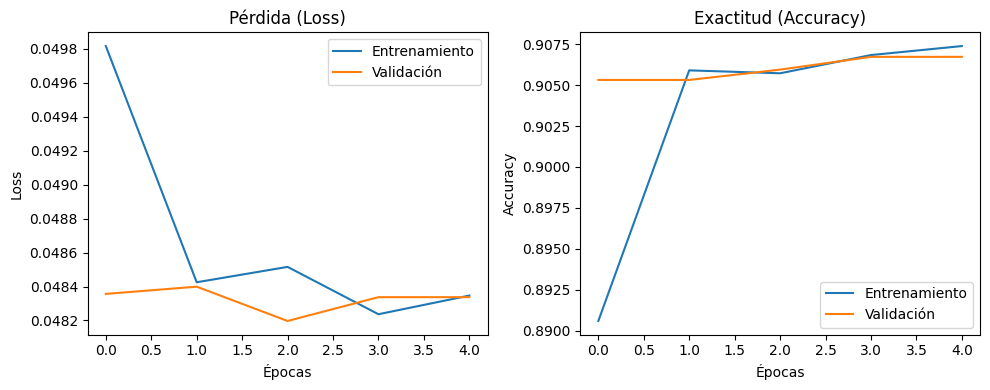

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

##7.Se genera la máscara que segmenta la ciudad entre población protegida y desprotegeida.

In [ ]:
maxXcoord, minXcoord = 367077.325, 333077.325
Xdiff = int((maxXcoord - minXcoord)/1000)
maxXcoord, minXcoord, Xdiff

(367077.325, 333077.325, 34)

In [ ]:
maxYcoord, minYcoord = 594375.354, 553375.354
Ydiff = int((maxYcoord - minYcoord)/1000)
maxYcoord, minYcoord, Ydiff

(594375.354, 553375.354, 41)

In [ ]:
with open(shared_folder_path+"chichago_mascara_protegidos.pkl", "rb") as file:
    mask = pickle.load(file)
mask = mask[::-1]
protectedMask = np.expand_dims(np.array(mask,dtype=np.uint8),axis=-1)
unprotectedMask = np.expand_dims(np.ones((Ydiff, Xdiff)) - mask,axis=-1)
protectedMask.shape, unprotectedMask.shape

((41, 34, 1), (41, 34, 1))

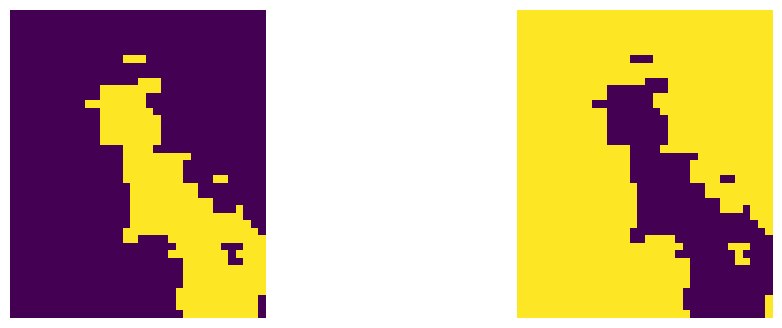

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].imshow(protectedMask)
axes[0].axis("off")

axes[1].imshow(unprotectedMask)
axes[1].axis("off")



plt.show()

## 8. Se hacen funciones para calcular de forma manual el error.
### Esto se hace debido a que se busca no tener en cuenta aquellos pixeles donde no hay predicciones.

In [ ]:
def count_predicted(frame,protected = True):
  mask = protectedMask if protected==True else unprotectedMask
  maskedFrame = np.multiply(frame, mask)
  valuesOn = {}
  for ypos in range(Ydiff):
    for xpos in range(Xdiff):
      if np.all(np.isclose(maskedFrame[ypos][xpos], 0)):
        continue
      valuesOn[(ypos,xpos)] = frame[ypos][xpos]
  return valuesOn



In [ ]:
def compare_predicted(realCounted, predictedCounted):
  batteryError, criminalDamageError, theftError = 0, 0, 0
  cont = 0
  toErase = []
  for pos in realCounted:
    cont += 1
    if pos not in predictedCounted:
      batteryError += realCounted[pos][0]**2
      criminalDamageError += realCounted[pos][1]**2
      theftError += realCounted[pos][2]**2
    else:
      batteryError += abs(realCounted[pos][0]-predictedCounted[pos][0])**2
      criminalDamageError += abs(realCounted[pos][1]-predictedCounted[pos][1])**2
      theftError += abs(realCounted[pos][2]-predictedCounted[pos][2])**2
      toErase.append(pos)

  for pos in toErase:
    realCounted.pop(pos)
    predictedCounted.pop(pos)

  for pos in predictedCounted:
    batteryError += predictedCounted[pos][0]**2
    criminalDamageError += predictedCounted[pos][1]**2
    theftError += predictedCounted[pos][2]**2
    cont+=1
  return batteryError/float(cont), criminalDamageError/float(cont), theftError/float(cont)

In [ ]:
res = compare_predicted(count_predicted(real[0],protected=True),count_predicted(results[0],protected = True))
print(res)

(0.4671655879180151, 0.23712243797195254, 0.2214131607335491)


## 9. Se calcula el error de predicción por cada tipo de crimen teniendo en cuenta población protegida y población desprotegida.

In [ ]:
batteryErrorProtected, criminalDamageErrorProtected, theftErrorProtected = [], [], []
batteryErrorUnprotected, criminalDamageErrorUnprotected, theftErrorUnprotected = [], [], []
for day in range(prediction_size):
  batteryError, criminalDamageError, theftError = compare_predicted(count_predicted(real[day],protected=True),count_predicted(results[day],protected = True))
  batteryErrorProtected.append(batteryError)
  criminalDamageErrorProtected.append(criminalDamageError)
  theftErrorProtected.append(theftError)

  batteryError, criminalDamageError, theftError = compare_predicted(count_predicted(real[day],protected=False),count_predicted(results[day],protected = False))
  batteryErrorUnprotected.append(batteryError)
  criminalDamageErrorUnprotected.append(criminalDamageError)
  theftErrorUnprotected.append(theftError)

In [ ]:
from datetime import datetime, timedelta

# Fecha inicial: 1 de enero de 2025
inicio = datetime(2025, 1, 1)

# Generar lista de 31 fechas consecutivas
fechas = [(inicio + timedelta(days=i)).date() for i in range(31)]
print(fechas)


[datetime.date(2025, 1, 1), datetime.date(2025, 1, 2), datetime.date(2025, 1, 3), datetime.date(2025, 1, 4), datetime.date(2025, 1, 5), datetime.date(2025, 1, 6), datetime.date(2025, 1, 7), datetime.date(2025, 1, 8), datetime.date(2025, 1, 9), datetime.date(2025, 1, 10), datetime.date(2025, 1, 11), datetime.date(2025, 1, 12), datetime.date(2025, 1, 13), datetime.date(2025, 1, 14), datetime.date(2025, 1, 15), datetime.date(2025, 1, 16), datetime.date(2025, 1, 17), datetime.date(2025, 1, 18), datetime.date(2025, 1, 19), datetime.date(2025, 1, 20), datetime.date(2025, 1, 21), datetime.date(2025, 1, 22), datetime.date(2025, 1, 23), datetime.date(2025, 1, 24), datetime.date(2025, 1, 25), datetime.date(2025, 1, 26), datetime.date(2025, 1, 27), datetime.date(2025, 1, 28), datetime.date(2025, 1, 29), datetime.date(2025, 1, 30), datetime.date(2025, 1, 31)]


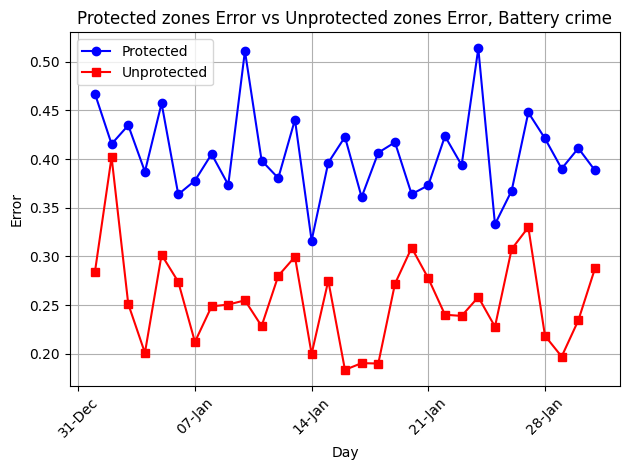

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Listas de ejemplo (mismo tamaño)
lista1 = batteryErrorProtected
lista2 = batteryErrorUnprotected


# Graficar ambas listas
plt.plot(fechas, lista1, marker='o', linestyle='-', color='blue', label='Protected')
plt.plot(fechas, lista2, marker='s', linestyle='-', color='red', label='Unprotected')

# Etiquetas y título
plt.xlabel('Day')
plt.ylabel('Error')
plt.title('Protected zones Error vs Unprotected zones Error, Battery crime')
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))  # Ej: 01-Jan
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Mostrar cada semana

plt.xticks(rotation=45)  # Rotar etiquetas del eje X
plt.legend()
plt.tight_layout()  # Ajustar diseño para que no se superpongan las etiquetas
plt.show()


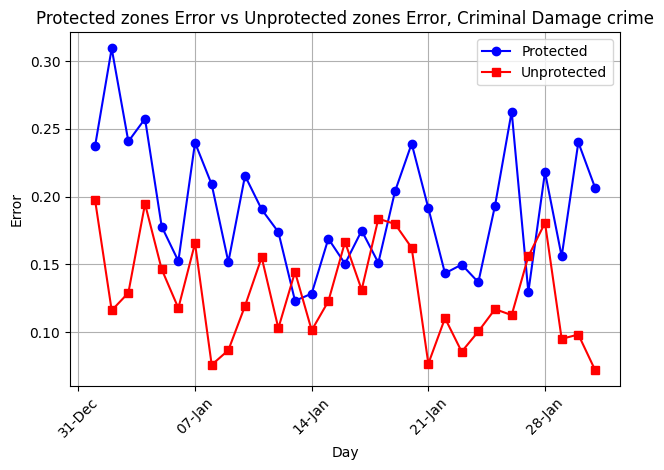

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Listas de ejemplo (mismo tamaño)
lista1 = criminalDamageErrorProtected
lista2 = criminalDamageErrorUnprotected

# Eje X será el índice de los elementos
x = range(len(lista1))

# Graficar ambas listas
plt.plot(fechas, lista1, marker='o', linestyle='-', color='blue', label='Protected')
plt.plot(fechas, lista2, marker='s', linestyle='-', color='red', label='Unprotected')

# Etiquetas y título
plt.xlabel('Day')
plt.ylabel('Error')
plt.title('Protected zones Error vs Unprotected zones Error, Criminal Damage crime')
plt.legend()
plt.grid(True)


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))  # Ej: 01-Jan
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Mostrar cada semana

plt.xticks(rotation=45)  # Rotar etiquetas del eje X
plt.legend()
plt.tight_layout()  # Ajustar diseño para que no se superpongan las etiquetas
plt.show()


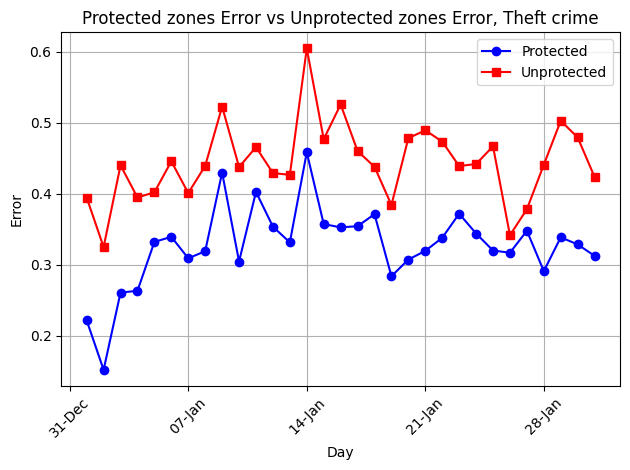

In [ ]:
0import matplotlib.pyplot as plt


# Listas de ejemplo (mismo tamaño)
lista1 = theftErrorProtected
lista2 = theftErrorUnprotected

# Eje X será el índice de los elementos
x = range(len(lista1))

# Graficar ambas listas
plt.plot(fechas, lista1, marker='o', linestyle='-', color='blue', label='Protected')
plt.plot(fechas, lista2, marker='s', linestyle='-', color='red', label='Unprotected')

# Etiquetas y título
plt.xlabel('Day')
plt.ylabel('Error')
plt.title('Protected zones Error vs Unprotected zones Error, Theft crime')
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))  # Ej: 01-Jan
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Mostrar cada semana

plt.xticks(rotation=45)  # Rotar etiquetas del eje X
plt.legend()
plt.tight_layout()  # Ajustar diseño para que no se superpongan las etiquetas
plt.show()


